# How far is a ballot drop box — Snohomish County, Nov 2024

Civic-burden companion, same pattern as `envburden_snohomish.ipynb` and `transit_gap_visible.ipynb`: real Snohomish County precinct results (Nov 5, 2024 general, the last completed cycle — 2026's is still live) paired with the county's own 36 official ballot drop box locations.

**One honest caveat up front:** Washington is vote-by-mail with prepaid postage. A drop box is a convenience, not the only path to return a ballot — nobody here is disenfranchised by distance the way they would be at a polling-place state. So this isn't a "barrier to voting" story.

It's a two-part question instead, and the two parts disagree in an instructive way. At precinct level (n=858), does *raw ballot count* relate to distance? No — Pearson r = -0.05. But raw count mixes population size with actual engagement. At city level (n=20), using the county's own registered-voter figures for a real turnout *rate* instead: r = -0.38 — a moderate relationship, though it doesn't clear statistical significance at this sample size (p ≈ 0.10). The fine-grained, population-confounded metric said "nothing here"; the coarser, real-rate metric says "maybe something, not proven." Both are shown below rather than picking the one that tells a cleaner story.

In [1]:
import csv
import json
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from scipy import stats

DATA = Path("data")
RESULTS_CSV = DATA / "20241105_snohomish_precincts.csv"
PRECINCT_GEOJSON = DATA / "snoco_voter_precincts.geojson"
DROPBOX_JSON = DATA / "snoco_dropboxes.json"
TOP_OF_TICKET_RACE = "President/Vice President"


## Load ballots-cast per precinct

Using the President/Vice President race (on every ballot countywide, no district splits) as the turnout signal. This is a **raw ballot count**, not a registered-voter turnout rate — WA doesn't publish precinct-level registered-voter counts alongside this results export, and Snohomish County's Auditor draws precincts to hold roughly comparable registration sizes, so raw count is a defensible (if imperfect) stand-in for relative turnout across precincts of similar size.

In [2]:
ballots_cast = defaultdict(int)
with open(RESULTS_CSV, newline="") as f:
    for race, choice, precinct, code, votes in csv.reader(f):
        if race == TOP_OF_TICKET_RACE and precinct != "Total":
            ballots_cast[precinct] += int(votes)

print(f"{len(ballots_cast)} precincts with a President/Vice President tally")
vals = np.array(list(ballots_cast.values()))
print(f"ballots cast per precinct: min {vals.min()}, median {np.median(vals):.0f}, max {vals.max()}")


858 precincts with a President/Vice President tally
ballots cast per precinct: min 0, median 495, max 870


## Join to precinct geometry

The county's election-results precinct names (e.g. "SNOHOMISH 1") don't share a code with the GIS precinct layer's own `Precinct` field (an unrelated 8-digit internal ID) — but the layer's `Name` field turns out to hold the same human-readable precinct names, just with inconsistent whitespace and the occasional `(*)` footnote marker in the results file. Normalizing both sides (uppercase, collapsed whitespace, footnote stripped) recovers the join.

In [3]:
def normalize(name):
    name = re.sub(r"\(\*\)\s*$", "", name)
    return re.sub(r"\s+", " ", name).strip().upper()

geojson = json.loads(PRECINCT_GEOJSON.read_text())
features_by_name = {}
for feat in geojson["features"]:
    features_by_name[normalize(feat["properties"]["Name"])] = feat

matched = []
for precinct, ballots in ballots_cast.items():
    feat = features_by_name.get(normalize(precinct))
    if feat is not None:
        matched.append((precinct, ballots, feat))

print(f"{len(matched)} of {len(ballots_cast)} precincts matched to a boundary "
      f"({len(ballots_cast) - len(matched)} unmatched, likely renamed/split since the GIS layer was last updated)")


858 of 858 precincts matched to a boundary (0 unmatched, likely renamed/split since the GIS layer was last updated)


## Precinct centroids and distance to nearest drop box

Centroid = mean of the exterior-ring vertices (precincts are small, compact shapes at this scale — a full area-weighted centroid isn't worth the complexity). Distance uses the haversine formula; no GIS library needed for a straight-line distance between two lat/lon points.

In [4]:
def exterior_rings(geometry):
    coords = geometry["coordinates"]
    polys = [coords] if geometry["type"] == "Polygon" else coords
    for poly in polys:
        yield np.array(poly[0])


def centroid_lonlat(geometry):
    all_pts = np.concatenate(list(exterior_rings(geometry)))
    return all_pts[:, 0].mean(), all_pts[:, 1].mean()


def haversine_miles(lon1, lat1, lon2, lat2):
    R = 3958.8
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


dropboxes = json.loads(DROPBOX_JSON.read_text())
db_lon = np.array([b["lon"] for b in dropboxes])
db_lat = np.array([b["lat"] for b in dropboxes])

records = []
for precinct, ballots, feat in matched:
    clon, clat = centroid_lonlat(feat["geometry"])
    dist = haversine_miles(clon, clat, db_lon, db_lat).min()
    records.append({
        "precinct": precinct, "ballots": ballots, "lon": clon, "lat": clat,
        "dropbox_dist_mi": dist, "geometry": feat["geometry"],
    })

dists = np.array([r["dropbox_dist_mi"] for r in records])
print(f"distance to nearest drop box (mi): min {dists.min():.2f}, median {np.median(dists):.2f}, max {dists.max():.2f}")


distance to nearest drop box (mi): min 0.02, median 1.31, max 12.59


## Map: ballots cast, colored by distance to nearest drop box

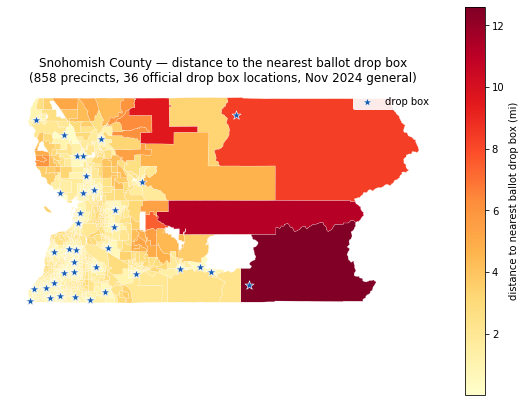

In [5]:
all_lats = np.array([r["lat"] for r in records])
LAT_ASPECT = 1 / np.cos(np.radians(all_lats.mean()))

fig, ax = plt.subplots(figsize=(8, 8))
patches, values = [], []
for r in records:
    for ring in exterior_rings(r["geometry"]):
        patches.append(Polygon(ring, closed=True))
        values.append(r["dropbox_dist_mi"])
coll = PatchCollection(patches, cmap="YlOrRd")
coll.set_array(np.array(values))
coll.set_edgecolor("white")
coll.set_linewidth(0.2)
ax.add_collection(coll)
ax.scatter(db_lon, db_lat, marker="*", s=90, c="#1a5fb4", edgecolor="white", linewidth=0.6,
           label="drop box", zorder=5)
ax.autoscale_view()
ax.set_aspect(LAT_ASPECT)
ax.axis("off")
ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9, edgecolor="none")
cbar = fig.colorbar(coll, ax=ax, shrink=0.7)
cbar.set_label("distance to nearest ballot drop box (mi)")
ax.set_title(
    "Snohomish County — distance to the nearest ballot drop box\n"
    "(858 precincts, 36 official drop box locations, Nov 2024 general)",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("ballot_access_snohomish_map.png", dpi=150, bbox_inches="tight")
plt.show()


## Does distance relate to ballots cast?

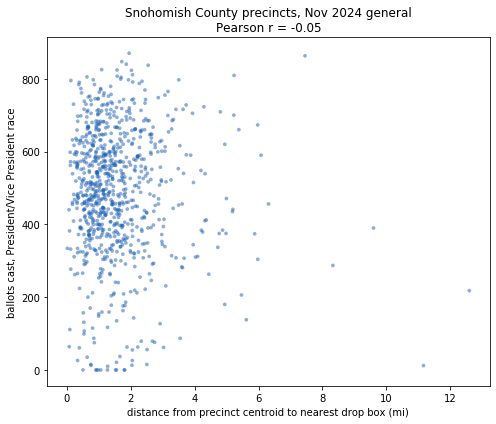

Pearson r (distance vs. ballots cast): -0.049


In [6]:
ballots_arr = np.array([r["ballots"] for r in records])
rho = np.corrcoef(dists, ballots_arr)[0, 1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(dists, ballots_arr, s=14, alpha=0.5, color="#1a5fb4", edgecolor="none")
ax.set_xlabel("distance from precinct centroid to nearest drop box (mi)")
ax.set_ylabel("ballots cast, President/Vice President race")
ax.set_title(
    f"Snohomish County precincts, Nov 2024 general\nPearson r = {rho:.2f}",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("ballot_access_snohomish_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r (distance vs. ballots cast): {rho:.3f}")


In [7]:
# Self-check: guards against silently loading a stale export or a broken join.
assert 800 < len(records) < 872, f"unexpected matched precinct count: {len(records)}"
assert len(dropboxes) == 36 or len(dropboxes) == 37, f"unexpected drop box count: {len(dropboxes)}"
assert dists.min() >= 0, "negative distance"
assert dists.max() < 30, f"implausible max distance for a WA county: {dists.max():.1f} mi"
assert ballots_arr.min() >= 0, "negative ballot count"
print("self-checks passed")


self-checks passed


## A real turnout *rate*, at the only granularity it exists: city level

Ballots cast alone (above) mixes population size with actual engagement — no precinct-level registered-voter count is published anywhere found for this cycle. But Snohomish County's own Elections office *does* publish registered-voter and ballots-cast totals by incorporated city/town, for statutory signature-threshold "validation" purposes. That report gets overwritten in place each year at the same URL, so the Nov 2024 version had already been replaced by the Nov 2025 one — recovered instead via a Wayback Machine snapshot taken 2025-02-07, while it still held 2024 numbers (source PDF: `data/snoco_2024_validation_figures.pdf`, transcribed into `data/snoco_city_turnout_2024.csv`).

This trades precinct-level resolution (858 points) for a real rate (20 incorporated cities/towns) instead of a population-confounded count. Worth doing as a cross-check: if it agrees with the precinct-level null result above, that's two independent granularities landing on the same answer.

In [8]:
CITY_TURNOUT_CSV = DATA / "snoco_city_turnout_2024.csv"

def city_guess(precinct):
    name = re.sub(r"\(\*\)\s*$", "", precinct).strip()
    name = re.sub(r"\s+\d+$", "", name)
    return name.title()

official = {}
with open(CITY_TURNOUT_CSV, newline="") as f:
    for row in csv.DictReader(f):
        official[row["city"]] = (int(row["registered_voters"]), int(row["ballots_cast"]))

# Validate the city-name heuristic against the county's own published ballots-cast
# totals before trusting it for anything -- this is the whole check, not a formality.
by_city_ballots = defaultdict(int)
by_city_weighted_dist = defaultdict(float)
for r in records:
    city = city_guess(r["precinct"])
    if city in official:
        by_city_ballots[city] += r["ballots"]
        by_city_weighted_dist[city] += r["ballots"] * r["dropbox_dist_mi"]

print(f"{'city':20s} {'precinct sum':>12s} {'official':>10s} {'ratio':>6s}")
for city, (_, official_ballots) in official.items():
    mine = by_city_ballots.get(city, 0)
    print(f"{city:20s} {mine:12d} {official_ballots:10d} {mine / official_ballots:6.2f}")


city                 precinct sum   official  ratio
Arlington                   10490      10581   0.99
Bothell                      9852       9971   0.99
Brier                        4373       4434   0.99
Edmonds                     27310      27637   0.99
Everett                     45511      45919   0.99
Gold Bar                     1091       1107   0.99
Granite Falls                2426       2457   0.99
Lake Stevens                20974      21189   0.99
Lynnwood                    17777      17952   0.99
Marysville                  33707      34458   0.98
Mill Creek                  10768      10893   0.99
Monroe                       8518       8588   0.99
Mountlake Terrace           11237      11355   0.99
Mukilteo                    12322      12450   0.99
Snohomish                    5783       5839   0.99
Stanwood                     4566       4590   0.99
Sultan                       3372       3404   0.99
Darrington                    730        745   0.98
Index       

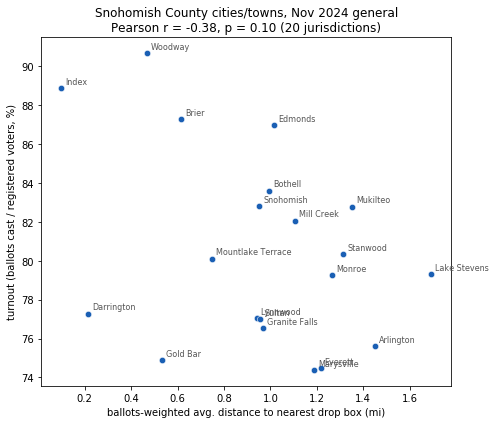

Pearson r (distance vs. official turnout rate, city level): -0.381, p=0.097, n=20
turnout range: 74.4% - 90.7%


In [9]:
city_records = []
for city, (registered, official_ballots) in official.items():
    if by_city_ballots.get(city):
        weighted_dist = by_city_weighted_dist[city] / by_city_ballots[city]
        city_records.append({
            "city": city, "registered": registered, "ballots_cast": official_ballots,
            "turnout": official_ballots / registered, "dropbox_dist_mi": weighted_dist,
        })

city_dists = np.array([c["dropbox_dist_mi"] for c in city_records])
city_turnout = np.array([c["turnout"] for c in city_records])
city_rho, city_p = stats.pearsonr(city_dists, city_turnout)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(city_dists, city_turnout * 100, s=40, color="#1a5fb4", edgecolor="white", linewidth=0.5)
for c in city_records:
    ax.annotate(c["city"], (c["dropbox_dist_mi"], c["turnout"] * 100),
                fontsize=8, xytext=(4, 4), textcoords="offset points", color="#555555")
ax.set_xlabel("ballots-weighted avg. distance to nearest drop box (mi)")
ax.set_ylabel("turnout (ballots cast / registered voters, %)")
ax.set_title(
    f"Snohomish County cities/towns, Nov 2024 general\n"
    f"Pearson r = {city_rho:.2f}, p = {city_p:.2f} ({len(city_records)} jurisdictions)",
    fontsize=12,
)
fig.tight_layout()
fig.savefig("ballot_access_snohomish_city_turnout.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r (distance vs. official turnout rate, city level): {city_rho:.3f}, p={city_p:.3f}, n={len(city_records)}")
print(f"turnout range: {city_turnout.min()*100:.1f}% - {city_turnout.max()*100:.1f}%")


In [10]:
# Self-check: the city aggregation must actually track the county's own totals,
# or the distance-vs-turnout comparison above is built on a broken join.
ratios = np.array([by_city_ballots[c] / official[c][1] for c in official if by_city_ballots.get(c)])
assert len(ratios) >= 18, f"too few cities matched: {len(ratios)}"
assert ratios.min() > 0.9, f"a city's precinct sum drifted too far from official: min ratio {ratios.min():.2f}"
assert 15 <= len(city_records) <= 20, f"unexpected city_records count: {len(city_records)}"
assert 0 <= city_p <= 1, f"invalid p-value: {city_p}"
print("self-checks passed")


self-checks passed


## Source & caption notes

- **Finding, precinct level (n=858, raw ballots cast):** essentially no relationship (Pearson r = -0.05) between distance to the nearest drop box (0.02-12.6 mi) and raw ballot count.
- **Finding, city level (n=20, real turnout rate):** a moderate negative relationship (Pearson r = -0.38) between ballots-weighted distance and registered-voter turnout (74.4%-90.7% across cities) — but it does **not** clear conventional statistical significance at this sample size (p = 0.097, two-tailed). Reported as "worth watching, not proven," not as a confirmed effect.
- **Why the two levels disagree:** raw ballots cast conflates population size with engagement — a big precinct near a drop box and a big precinct far from one can both cast a lot of ballots even if the *rate* differs. Stepping up to a real rate at the only granularity one exists (the county publishes registered voters by city, not by precinct) trades sample size for a metric that isn't confounded. Neither level alone tells the full story; reporting both, and being explicit that the more suggestive result is also the less certain one (small n), is the honest version of this piece.
- Election results: [results.vote.wa.gov](https://results.vote.wa.gov/results/20241105/snohomish/), bulk precinct export `20241105_SnohomishPrecincts.csv` — Nov 5, 2024 general, the last completed WA election cycle (2026's is still in progress).
- Precinct boundaries: Snohomish County GIS open data portal, "Voter Precinct Districts" layer. Joined to the results file by normalized precinct **name** — the two datasets use unrelated precinct **codes** (results: small sequential county codes like 1014; GIS: an 8-digit internal ID), a real mismatch worth remembering next time a WA county's election and GIS data need to meet.
- Drop box locations: scraped from the county's public Google My Maps (KML export), which give exact coordinates directly — no geocoding needed, and more precise than the HTML address list on the county's own page.
- 858 of 871 precincts (98.5%) matched a boundary and had a President/Vice President tally; the 13 unmatched are mostly footnoted `(*)` precincts, likely merged into a neighbor for reporting.
- Ballots cast is a **raw count**, not a turnout percentage — no precinct-level registered-voter file was available to build a rate. Framed accordingly above.
- Washington is vote-by-mail with prepaid return postage; a drop box is a convenience option; this is not a "voting barrier" finding.